# Atividade 01 — Caracterização e avaliação inicial dos dados

Análise dos **100 cenários publicados** e do projeto de exemplo `EV_00000.xlsx`. As trajetórias são sintéticas. O objetivo é verificar se os dados sustentam a geração e análise de cenários para apoiar decisões de cronograma e capacidade.

A base está em `data/simulacoes_100/dataset_projeto.npz`, com seus metadados na mesma pasta. O caminho de entrada é definido em `ARQUIVO_CENARIOS`, na primeira célula de código. As atividades são lidas diretamente do Excel.

Para reproduzir, instale `pandas`, `numpy`, `openpyxl`, `matplotlib` e `ipykernel` no ambiente Python e execute todas as células, a partir da raiz do projeto ou da pasta `notebooks`. As figuras ficam no próprio notebook.

In [1]:
from pathlib import Path
import csv
import hashlib
import json
import platform
import warnings
import importlib.metadata
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/EV_00000.xlsx').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Execute a partir da raiz do projeto ou da pasta notebooks.')
DATA = ROOT / 'data'
# Caminho da base analisada.
ARQUIVO_CENARIOS = DATA / 'simulacoes_100' / 'dataset_projeto.npz'
HORIZONTE = 60  # tu; referência desta análise, não prazo contratual
LIMIAR_CONCLUSAO = 100.0

proveniencia = json.loads((DATA / 'proveniencia.json').read_text(encoding='utf-8'))
colunas_csv = ['simulation_id','Expected_Rew','Expected_WU','PCronograma','PGestor',
               'Variacao_Capacidade_Base_Pct','SimTime','PercAccomplished','WD','WRemaining']
if ARQUIVO_CENARIOS.suffix.lower() == '.csv':
    df = pd.read_csv(ARQUIVO_CENARIOS, encoding='utf-8')
elif ARQUIVO_CENARIOS.suffix.lower() == '.npz':
    metadata_npz = json.loads(ARQUIVO_CENARIOS.with_name('metadata.json').read_text(encoding='utf-8'))
    with np.load(ARQUIVO_CENARIOS) as arq:
        X, Y = arq['X'], arq['Y']
        ids_npz = arq['simulation_id'] if 'simulation_id' in arq.files else np.arange(len(X))
    if X.ndim != 3 or Y.ndim != 3 or X.shape[:2] != Y.shape[:2]:
        raise ValueError('Esperado NPZ de projeto com eixos cenário, tempo e variável.')
    n_cenarios, n_tempos = X.shape[:2]
    if len(ids_npz) != n_cenarios or len(np.unique(ids_npz)) != n_cenarios:
        raise ValueError('IDs de cenário inválidos no NPZ.')
    valores = {'simulation_id': np.repeat(ids_npz,n_tempos)}
    for nome in colunas_csv[1:7]:
        valores[nome] = X[:,:,metadata_npz['input_names']['projeto'].index(nome)].reshape(-1)
    for nome in colunas_csv[7:]:
        valores[nome] = Y[:,:,metadata_npz['output_names'].index(nome)].reshape(-1)
    df = pd.DataFrame(valores)
    del X, Y, valores
else:
    raise ValueError('Selecione CSV ou dataset_projeto.npz.')
if set(df.columns) != set(colunas_csv):
    raise ValueError('As colunas da base diferem das esperadas: '+str(list(df.columns)))
amostra_csv = ARQUIVO_CENARIOS.resolve() == (DATA/'cenarios.csv').resolve()
amostra_npz = ARQUIVO_CENARIOS.resolve() == (DATA/'simulacoes_100/dataset_projeto.npz').resolve()
amostra_publicada = amostra_csv or amostra_npz
N_CENARIOS = df.simulation_id.nunique()
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Data Validation extension is not supported.*')
    wb = openpyxl.load_workbook(DATA / 'EV_00000.xlsx', data_only=True)
    wb_formulas = openpyxl.load_workbook(DATA / 'EV_00000.xlsx', data_only=False)
versoes = {p: importlib.metadata.version(p) for p in ['pandas','numpy','openpyxl','matplotlib']}
print('Python:', platform.python_version(), '| Bibliotecas:', versoes)
print('Base selecionada:',ARQUIVO_CENARIOS.name,'| Cenários:',N_CENARIOS)
for arquivo, chave in [(ARQUIVO_CENARIOS,'amostra_sha256' if amostra_csv else ('simulacoes_npz_sha256' if amostra_npz else None)),
                        (DATA/'EV_00000.xlsx','planilha_sha256')]:
    with arquivo.open('rb') as stream:
        sha = hashlib.file_digest(stream,'sha256').hexdigest()
    if chave:
        assert sha == proveniencia[chave], f'Arquivo diferente da versão documentada: {arquivo.name}'
    print(arquivo.name, '— SHA-256:', sha)
display(df.head())
if amostra_npz:
    assert hashlib.sha256(ARQUIVO_CENARIOS.with_name('metadata.json').read_bytes()).hexdigest() == proveniencia['simulacoes_metadata_sha256']
    csv_referencia = pd.read_csv(DATA/'cenarios.csv').sort_values(['simulation_id','SimTime'])
    assert np.allclose(df.sort_values(['simulation_id','SimTime'])[colunas_csv], csv_referencia[colunas_csv], rtol=1e-7, atol=1e-6)
    print('Recorte NPZ e CSV existente representam os mesmos 100 cenários.')

Python: 3.12.14 | Bibliotecas: {'pandas': '3.0.1', 'numpy': '2.3.5', 'openpyxl': '3.1.5', 'matplotlib': '3.11.1'}
Base selecionada: dataset_projeto.npz | Cenários: 100
dataset_projeto.npz — SHA-256: 8cabf87d4fabbb8e4f8d6c0e84200cf01d6aad6aca2a8993ab9600010374ab41
EV_00000.xlsx — SHA-256: 96e65da2519e8b09c1fb8406635cb022e5d9e024e75bc2587aa74a6bb11a5fae


,simulation_id,Expected_Rew,Expected_WU,PCronograma,PGestor,Variacao_Capacidade_Base_Pct,SimTime,PercAccomplished,WD,WRemaining
0,0,4.793077,6.847797,4.913934,29.610113,21.126163,0.0,0.000000,0.000000,54912.000000
1,0,4.793077,6.847797,4.913934,29.610113,21.126163,1.0,7.874789,4692.196777,50234.171875
2,0,4.793077,6.847797,4.913934,29.610113,21.126163,2.0,15.675222,9384.394531,45640.390625
3,0,4.793077,6.847797,4.913934,29.610113,21.126163,3.0,23.135227,14076.909180,41289.015625
4,0,4.793077,6.847797,4.913934,29.610113,21.126163,4.0,30.087097,18799.902344,37158.781250


Recorte NPZ e CSV existente representam os mesmos 100 cenários.


## 1. Fonte, estrutura e unidade de análise

A fonte principal é a saída de experimentos do simulador do mestrado, lote `20260818_225211`. A amostra seleciona índices 0, 100, ..., 9900 da base de origem. É uma seleção sistemática, sem filtro por desfecho, mas sem garantia de representatividade. O responsável pela organização dos experimentos e pela amostra é Rafael S. Valadão.

Os tensores do NPZ são convertidos em uma tabela em memória, com **um cenário em um instante** por linha. A unidade de comparação de condições de execução é o cenário. A atualização depende de novos experimentos; não há coleta operacional periódica. Somente resultados e o Excel representativo são compartilhados, sem o código do simulador.

In [2]:
parametros = ['Expected_Rew','Expected_WU','PCronograma','PGestor','Variacao_Capacidade_Base_Pct']
chave = ['simulation_id','SimTime']
ordenado = df.sort_values(chave)
por_cenario = ordenado.groupby('simulation_id', sort=True)
ids_esperados = set(range(0,10000,100))
resumo_fonte = pd.Series({
    'registros temporais': len(df), 'colunas': len(df.columns),
    'cenários': df.simulation_id.nunique(),
    'instantes por cenário (mínimo)': int(por_cenario.size().min()),
    'instantes por cenário (máximo)': int(por_cenario.size().max()),
    'tempo mínimo (tu)': df.SimTime.min(), 'tempo máximo (tu)': df.SimTime.max(),
    'seleção coincide com índices documentados': (set(df.simulation_id) == ids_esperados) if amostra_publicada else 'não se aplica à base alternativa',
})
display(resumo_fonte.to_frame('valor'))
display(pd.DataFrame({'arquivo':[ARQUIVO_CENARIOS.name,'EV_00000.xlsx'],
                      'bytes':[f.stat().st_size for f in [ARQUIVO_CENARIOS,DATA/'EV_00000.xlsx']]}))

,valor
registros temporais,6100
colunas,10
cenários,100
instantes por cenário (mínimo),61
instantes por cenário (máximo),61
tempo mínimo (tu),0.0
tempo máximo (tu),60.0
seleção coincide com índices documentados,True


,arquivo,bytes
0,dataset_projeto.npz,289088
1,EV_00000.xlsx,27810


## 2. Qualidade dos dados de simulação

As verificações numéricas abaixo se aplicam à tabela carregada da base selecionada. Valores repetidos dos parâmetros ao longo do tempo são esperados. Uma curva estacionária também não constitui, por si só, duplicidade. São verificadas linhas integralmente repetidas e repetição da chave cenário/instante. Os limites numéricos abaixo vêm das configurações documentadas dos experimentos; não são intervalos estimados de projetos reais.

In [3]:
qualidade = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'ausentes': df.isna().sum(),
    'ausentes_pct': df.isna().mean()*100,
    'nao_finitos': (~np.isfinite(df.select_dtypes('number'))).sum(),
    'minimo': df.min(), 'maximo': df.max(),
})
display(qualidade)
grade_incorreta = [int(sid) for sid,g in por_cenario
                   if g.SimTime.tolist() != list(range(61))]
parametros_variaveis = int((por_cenario[parametros].nunique() != 1).any(axis=1).sum())
limites = {p:(0,30) for p in parametros[:4]}
limites[parametros[4]]=(-20,30)
fora_limites = {p:int((~df[p].between(*limites[p])).sum()) for p in parametros}
queda_progresso = int((por_cenario['PercAccomplished'].diff() < -1e-6).sum())
if ARQUIVO_CENARIOS.suffix.lower()=='.csv':
    with ARQUIVO_CENARIOS.open(encoding='utf-8',newline='') as f:
        cabecalho = next(csv.reader(f))
    caracteres_invalidos = ARQUIVO_CENARIOS.read_text(encoding='utf-8').count('\ufffd')
else:
    cabecalho = list(df.columns)
    caracteres_invalidos = 'não se aplica ao formato binário NPZ'
auditoria_csv = {
    'linhas duplicadas': int(df.duplicated().sum()),
    'chaves duplicadas': int(df.duplicated(chave).sum()),
    'nomes de colunas duplicados': len(cabecalho)-len(set(cabecalho)),
    'cenários com grade diferente de 0..60': len(grade_incorreta),
    'cenários com parâmetros não constantes': parametros_variaveis,
    'quedas de progresso (tolerância 1e-6)': queda_progresso,
    'progresso fora de 0..100': int((~df.PercAccomplished.between(0,100)).sum()),
    'trabalho realizado negativo': int((df.WD < 0).sum()),
    'trabalho restante negativo': int((df.WRemaining < 0).sum()),
    'combinações de parâmetros repetidas entre cenários': int(por_cenario[parametros].first().duplicated().sum()),
    'caracteres de substituição Unicode no CSV': caracteres_invalidos,
}
display(pd.Series(auditoria_csv).to_frame('quantidade'))
display(pd.Series(fora_limites,name='registros fora do intervalo'))

,tipo,ausentes,ausentes_pct,nao_finitos,minimo,maximo
simulation_id,int64,0,0.0,0,0.000000,9900.000000
Expected_Rew,float32,0,0.0,0,0.447163,28.497101
Expected_WU,float32,0,0.0,0,0.472385,29.711641
PCronograma,float32,0,0.0,0,0.043216,28.953836
PGestor,float32,0,0.0,0,0.070998,29.734156
Variacao_Capacidade_Base_Pct,float32,0,0.0,0,-19.886545,29.665407
SimTime,float32,0,0.0,0,0.000000,60.000000
PercAccomplished,float32,0,0.0,0,0.000000,100.000000
WD,float32,0,0.0,0,0.000000,71144.882812
WRemaining,float32,0,0.0,0,0.000000,54912.000000


,quantidade
linhas duplicadas,0
chaves duplicadas,0
nomes de colunas duplicados,0
cenários com grade diferente de 0..60,0
cenários com parâmetros não constantes,0
quedas de progresso (tolerância 1e-6),0
progresso fora de 0..100,0
trabalho realizado negativo,0
trabalho restante negativo,0
combinações de parâmetros repetidas entre cenários,0


Expected_Rew                    0
Expected_WU                     0
PCronograma                     0
PGestor                         0
Variacao_Capacidade_Base_Pct    0
Name: registros fora do intervalo, dtype: int64

## 3. Inspeção do Excel de exemplo

As abas contêm notas, unidades e tabelas auxiliares além dos registros. Essas células não devem entrar no denominador de valores ausentes. Atividades e membros são lidos do primeiro bloco contíguo abaixo do cabeçalho, até a primeira linha sem identificador; o cadastro do projeto ocupa a segunda linha da aba `Projeto`. Filtrar somente por valores numéricos na aba inteira incluiria números de tabelas auxiliares como se fossem membros. A leitura utiliza valores calculados armazenados no arquivo, sem recalcular ou modificar fórmulas.

In [4]:
def tabela_identificada(aba, id_col):
    linhas = list(wb[aba].iter_rows(values_only=True))
    cabecalho = list(linhas[0])
    fim = next((i for i,c in enumerate(cabecalho) if c is None),len(cabecalho))
    registros=[]
    for row in linhas[1:]:
        if row[cabecalho.index(id_col)] is None:
            break
        registros.append(row[:fim])
    tabela = pd.DataFrame(registros,columns=cabecalho[:fim])
    return tabela.loc[pd.to_numeric(tabela[id_col],errors='coerce').notna()].copy()

atividades = tabela_identificada('Atividades','task_id')
equipe = tabela_identificada('Equipe','member_id')
for campo in ['task_id','expected_ini_tu','expected_end_tu','expected_duration','expected_wu','expected_workrate']:
    atividades[campo] = pd.to_numeric(atividades[campo],errors='raise')
campos_atividade = ['task_id','task_description','expected_ini_tu','expected_end_tu',
                   'expected_duration','expected_wu','expected_workrate','predecessoras']
display(pd.DataFrame([{'aba':s.title,'linhas dimensionadas':s.max_row,
                       'colunas dimensionadas':s.max_column} for s in wb]))
display(atividades[campos_atividade])
display(pd.DataFrame({'registros':[1,len(equipe),len(atividades)],
                      'fonte':['Projeto!A2:H2','Equipe!A2:M5','Atividades!A2:AR8']}))
display(atividades[campos_atividade].isna().agg(['sum','mean']).rename(index={'sum':'ausentes','mean':'fração ausente'}))
display(equipe[['member_id','name','dedication_tu','capacity']].isna().sum().to_frame('ausentes'))

formula_total=0; sem_cache=[]; erros=[]
for s in wb_formulas:
    valores = wb[s.title]
    for row in s:
        for c in row:
            if c.data_type=='f':
                formula_total += 1
                if valores[c.coordinate].value is None:
                    sem_cache.append((s.title,c.coordinate))
            if valores[c.coordinate].data_type=='e':
                erros.append((s.title,c.coordinate,valores[c.coordinate].value))
print('Fórmulas:',formula_total,'| Fórmulas sem valor armazenado:',len(sem_cache),'| Erros de célula:',len(erros))
print('Tipos de predecessoras:',atividades.predecessoras.map(lambda x:type(x).__name__).value_counts().to_dict())

def predecessores(value):
    if isinstance(value,(int,float,np.number)):
        return [] if value==0 else [int(value)]
    return [int(x.strip()) for x in str(value).split(',') if x.strip() and x.strip()!='0']
arestas=[(int(row.task_id),p) for row in atividades.itertuples() for p in predecessores(row.predecessoras)]
ids=set(atividades.task_id.astype(int))
invalidos=[(t,p) for t,p in arestas if p not in ids or t==p]
fins=atividades.set_index('task_id').expected_end_tu
inicios=atividades.set_index('task_id').expected_ini_tu
precedencia_temporal=[(t,p) for t,p in arestas if p in ids and inicios[t]<fins[p]]
grafo={int(r.task_id):predecessores(r.predecessoras) for r in atividades.itertuples()}
def ciclo(no,caminho):
    return no in caminho or any(ciclo(p,caminho|{no}) for p in grafo.get(no,[]))
display(pd.Series({
    'IDs de atividades duplicados':int(atividades.task_id.duplicated().sum()),
    'IDs de membros duplicados':int(equipe.member_id.duplicated().sum()),
    'duração diferente de término menos início':int((~np.isclose(atividades.expected_duration,atividades.expected_end_tu-atividades.expected_ini_tu)).sum()),
    'esforço diferente de duração vezes taxa':int((~np.isclose(atividades.expected_wu,atividades.expected_duration*atividades.expected_workrate)).sum()),
    'predecessores inválidos ou autorreferentes':len(invalidos),
    'início anterior ao término de predecessor':len(precedencia_temporal),
    'ciclo na rede':any(ciclo(no,set()) for no in grafo),
}).to_frame('resultado'))
projeto_id=wb['Projeto']['A2'].value
display(pd.Series({'ID no cadastro':projeto_id,'ID no nome do arquivo':'EV_00000',
    'duração cadastrada (meses)':wb['Projeto']['D2'].value,
    'duração cadastrada (tu/semanas)':wb['Projeto']['F2'].value,
    'último término de atividade (tu)':atividades.expected_end_tu.max(),
    'horizonte da simulação (tu)':df.SimTime.max(),
    'esforço total planejado (wu)':atividades.expected_wu.sum()}).to_frame('valor'))

,aba,linhas dimensionadas,colunas dimensionadas
0,TabelaSIGITEC,22,11
1,Projeto,22,10
2,Equipe,41,16
3,Atividades,9,44


,task_id,task_description,expected_ini_tu,expected_end_tu,expected_duration,expected_wu,expected_workrate,predecessoras
0,1,Descrição Atividade 1,0,12,12,11580,965.000000,0
1,2,Descrição Atividade 2,0,7,7,8440,1205.714286,0
2,3,Descrição Atividade 3,0,7,7,6780,968.571429,0
3,4,Descrição Atividade 4,12,22,10,9260,926.000000,"1,2,3"
4,5,Descrição Atividade 5,14,22,8,5292,661.500000,0
5,6,Descrição Atividade 6,22,37,15,9300,620.000000,"4,5"
6,7,Descrição Atividade 7,37,45,8,4260,532.500000,6


,registros,fonte
0,1,Projeto!A2:H2
1,4,Equipe!A2:M5
2,7,Atividades!A2:AR8


,task_id,task_description,expected_ini_tu,expected_end_tu,expected_duration,expected_wu,expected_workrate,predecessoras
ausentes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fração ausente,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,ausentes
member_id,0
name,0
dedication_tu,0
capacity,0


Fórmulas: 444 | Fórmulas sem valor armazenado: 0 | Erros de célula: 0
Tipos de predecessoras: {'int': 5, 'str': 2}


,resultado
IDs de atividades duplicados,0
IDs de membros duplicados,0
duração diferente de término menos início,0
esforço diferente de duração vezes taxa,0
predecessores inválidos ou autorreferentes,0
início anterior ao término de predecessor,0
ciclo na rede,False


,valor
ID no cadastro,EV-00000
ID no nome do arquivo,EV_00000
duração cadastrada (meses),12
duração cadastrada (tu/semanas),52.8
último término de atividade (tu),45
horizonte da simulação (tu),60.0
esforço total planejado (wu),54912


A coluna `predecessoras` mistura inteiros (0 para ausência de predecessora e 6 para uma predecessora) com listas em texto (`1,2,3`). Essa heterogeneidade exige conversão explícita, mas não constitui ausência. O cadastro usa `EV-00000`, enquanto o arquivo usa `EV_00000`: uma integração por identificador precisa definir esse mapeamento.

A planilha declara `tu` como semanas e usa 4,4 semanas por mês. A duração cadastrada é 52,8 tu, o último término das atividades é 45 tu e o experimento observa até 60 tu. Os três valores têm papéis distintos; esta análise mede **conclusão até 60 tu**, sem escolher arbitrariamente um prazo contratual. Não há uma coluna de data de medição com progresso real nesta amostra.

## 4. Distribuição das condições de execução

Estatísticas e histogramas dos parâmetros usam uma linha por cenário. Usar todas as linhas repetiria cada configuração por instante e confundiria o tamanho da amostra. As distribuições descrevem a base selecionada, não uma população de projetos reais.

,min,25%,50%,mean,75%,max
Expected_Rew,0.447,4.877,11.895,13.098,20.361,28.497
Expected_WU,0.472,7.273,16.742,15.766,23.355,29.712
PCronograma,0.043,6.693,15.090,14.580,21.514,28.954
PGestor,0.071,8.711,15.052,15.789,24.079,29.734
Variacao_Capacidade_Base_Pct,-19.887,-8.231,1.905,2.939,13.385,29.665


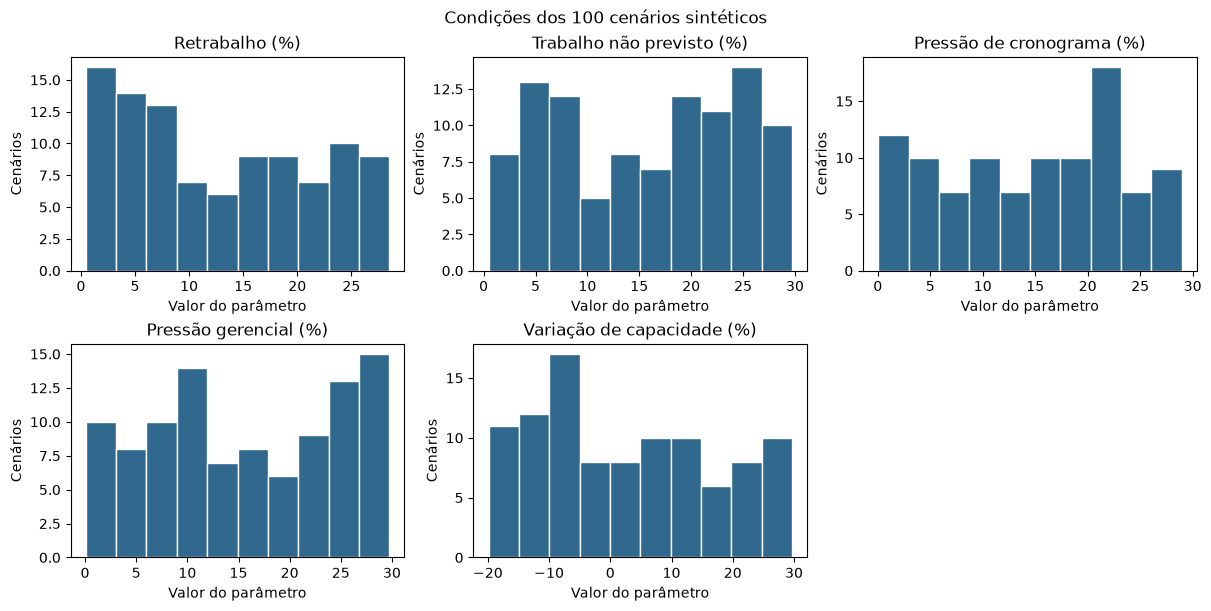

In [5]:
configuracoes = por_cenario[parametros].first()
display(configuracoes.describe().T[['min','25%','50%','mean','75%','max']].round(3))
fig,axes=plt.subplots(2,3,figsize=(12,6),layout='constrained')
titulos=['Retrabalho (%)','Trabalho não previsto (%)','Pressão de cronograma (%)',
         'Pressão gerencial (%)','Variação de capacidade (%)']
for ax,col,titulo in zip(axes.flat,parametros,titulos):
    ax.hist(configuracoes[col],bins=10,color='#31688e',edgecolor='white')
    ax.set(title=titulo,ylabel='Cenários',xlabel='Valor do parâmetro')
axes.flat[-1].set_visible(False)
fig.suptitle(f'Condições dos {N_CENARIOS:,} cenários sintéticos')
plt.show()

## 5. Progresso e conclusão no horizonte

Conclusão é o primeiro instante observado com `PercAccomplished >= 100`. Quando esse instante não existe, o tempo de conclusão permanece ausente, com significado conhecido: não concluído até 60 tu. Não se substitui essa ausência por zero ou por 60.

A distribuição do tempo de conclusão considera apenas os concluídos. A média condicional não é uma estimativa de duração para todos os cenários. A amplitude entre curvas reflete variação dos cenários amostrados e não um intervalo de confiança.

,valor
cenários concluídos até 60 tu,85.000
cenários não concluídos até 60 tu,15.000
frequência de conclusão na amostra (%),85.000
tempo médio entre concluídos (tu),48.235
tempo mediano entre concluídos (tu),47.000
progresso final médio (%),98.772
déficit médio entre não concluídos (pp),8.188
ausências derivadas em tempo_conclusao_tu,15.000


,Expected_Rew,Expected_WU,PCronograma,PGestor,Variacao_Capacidade_Base_Pct,progresso_final_pct,tempo_conclusao_tu,concluiu_ate_60,deficit_final_pp
simulation_id,,,,,,,,,
0,4.793077,6.847797,4.913934,29.610113,21.126163,100.000000,43.0,True,0.000000
100,11.229091,15.240011,0.684328,29.295662,28.712343,100.000000,44.0,True,0.000000
200,4.806226,5.438432,28.821270,10.456480,9.910745,100.000000,43.0,True,0.000000
300,28.027174,15.280879,18.996441,7.478281,-5.040786,96.128929,NaN,False,3.871071
400,17.084663,24.677662,18.208736,13.641801,14.962461,100.000000,48.0,True,0.000000


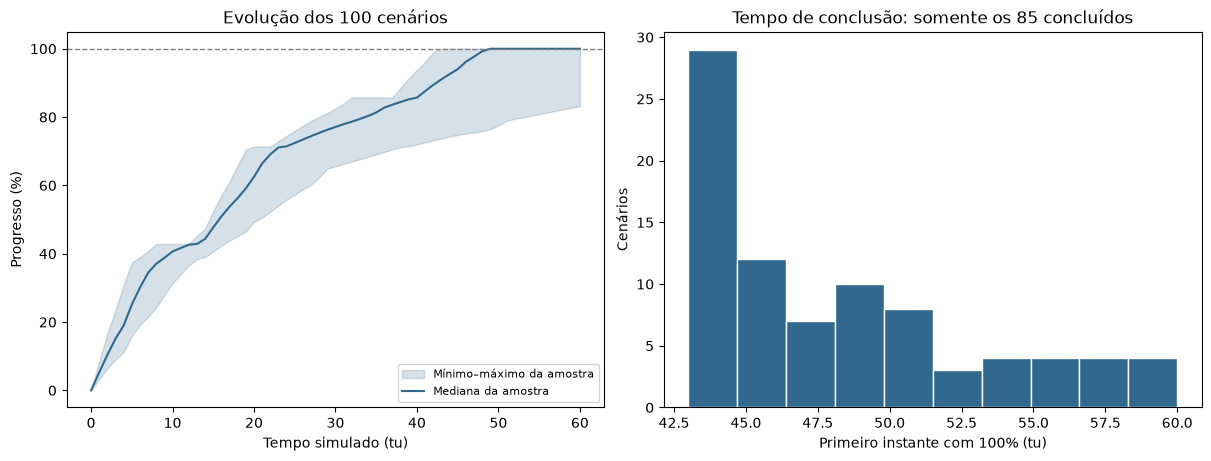

Frequência na base selecionada: 85.00%; referência da origem: 86.74% (metadado).
Nenhuma dessas frequências é uma probabilidade real calibrada de conclusão.


In [6]:
final = ordenado.groupby('simulation_id').tail(1).set_index('simulation_id')
tempos = df.loc[(df.PercAccomplished >= LIMIAR_CONCLUSAO) & (df.SimTime <= HORIZONTE)].groupby('simulation_id').SimTime.min()
desfechos = configuracoes.copy()
desfechos['progresso_final_pct']=final.PercAccomplished
desfechos['tempo_conclusao_tu']=tempos.reindex(desfechos.index)
desfechos['concluiu_ate_60']=desfechos.tempo_conclusao_tu.notna()
desfechos['deficit_final_pp']=np.maximum(0,100-desfechos.progresso_final_pct)
indicadores = pd.Series({
    'cenários concluídos até 60 tu':int(desfechos.concluiu_ate_60.sum()),
    'cenários não concluídos até 60 tu':int((~desfechos.concluiu_ate_60).sum()),
    'frequência de conclusão na amostra (%)':desfechos.concluiu_ate_60.mean()*100,
    'tempo médio entre concluídos (tu)':tempos.mean(),
    'tempo mediano entre concluídos (tu)':tempos.median(),
    'progresso final médio (%)':desfechos.progresso_final_pct.mean(),
    'déficit médio entre não concluídos (pp)':desfechos.loc[~desfechos.concluiu_ate_60,'deficit_final_pp'].mean(),
    'ausências derivadas em tempo_conclusao_tu':desfechos.tempo_conclusao_tu.isna().sum(),
})
display(indicadores.to_frame('valor').round(3))
display(desfechos.head())
agregado = df.groupby('SimTime').PercAccomplished.agg(['min','median','max'])
fig,axes=plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
axes[0].fill_between(agregado.index,agregado['min'],agregado['max'],alpha=.2,color='#31688e',label='Mínimo–máximo da amostra')
axes[0].plot(agregado.index,agregado['median'],color='#31688e',label='Mediana da amostra')
axes[0].axhline(100,color='gray',linestyle='--',linewidth=1)
axes[0].set(xlabel='Tempo simulado (tu)',ylabel='Progresso (%)',title=f'Evolução dos {N_CENARIOS:,} cenários')
axes[0].legend(fontsize=8)
axes[1].hist(tempos,bins=10,color='#31688e',edgecolor='white')
axes[1].set(xlabel='Primeiro instante com 100% (tu)',ylabel='Cenários',title=f'Tempo de conclusão: somente os {len(tempos)} concluídos')
plt.show()
freq_origem = 100*proveniencia['concluidos_origem']/proveniencia['n_simulacoes_origem']
print(f'Frequência na base selecionada: {desfechos.concluiu_ate_60.mean()*100:.2f}%; referência da origem: {freq_origem:.2f}% (metadado).')
print('Nenhuma dessas frequências é uma probabilidade real calibrada de conclusão.')

## 6. Implicações para o projeto

- Os dados permitem comparar curvas, condições e conclusão dentro do horizonte, mantendo a proposta de apoio ao planejamento com informações simuladas.
- A amostra não permite comprovar validade em execução real, estimar probabilidades operacionais ou isolar efeitos causais dos parâmetros. Faltam medições reais e cenários controlados que variem um parâmetro por vez.
- Antes de emitir um alerta de atraso, o sistema precisa definir qual prazo é a referência. Os tempos 45, 52,8 e 60 tu não são intercambiáveis.
- Ausência no tempo de conclusão derivado tem significado diferente de falha de coleta. O código mantém essa distinção.
- Não há alteração da hipótese ou da arquitetura da Aula 01. A análise delimita a interpretação dos indicadores e a limpeza necessária na entrada Excel.

A caracterização e a síntese técnica estão em `docs/atividade-01-dados.md`.